In [1]:
import kagglehub

path = kagglehub.dataset_download("berkeleyearth/climate-change-earth-surface-temperature-data")
print(path)

100%|██████████| 84.7M/84.7M [00:02<00:00, 34.2MB/s]

Extracting files...


/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2


In [2]:
import os
print(os.listdir(path))

['GlobalLandTemperaturesByCity.csv', 'GlobalLandTemperaturesByCountry.csv', 'GlobalLandTemperaturesByMajorCity.csv', 'GlobalLandTemperaturesByState.csv', 'GlobalTemperatures.csv']


In [3]:
import pandas as pd

path = "/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/1"

# Cargar el más completo
df = pd.read_csv(f"{path}/GlobalLandTemperaturesByCity.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())


FileNotFoundError: [Errno 2] No such file or directory: '/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/1/GlobalLandTemperaturesByCity.csv'

In [4]:
import os

base = "/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data"
for root, dirs, files in os.walk(base):
    for file in files:
        print(os.path.join(root, file))
        

/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/2.complete
/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2/GlobalLandTemperaturesByCity.csv
/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2/GlobalLandTemperaturesByCountry.csv
/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2/GlobalLandTemperaturesByMajorCity.csv
/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2/GlobalLandTemperaturesByState.csv
/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2/GlobalTemperatures.csv


In [5]:
import pandas as pd

path = "/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2"

df = pd.read_csv(f"{path}/GlobalLandTemperaturesByCity.csv")

print(df.shape)
print(df.head())
print(df.isnull().sum())

(8599212, 7)
           dt  AverageTemperature  AverageTemperatureUncertainty   City  \
0  1743-11-01               6.068                          1.737  Århus   
1  1743-12-01                 NaN                            NaN  Århus   
2  1744-01-01                 NaN                            NaN  Århus   
3  1744-02-01                 NaN                            NaN  Århus   
4  1744-03-01                 NaN                            NaN  Århus   

   Country Latitude Longitude  
0  Denmark   57.05N    10.33E  
1  Denmark   57.05N    10.33E  
2  Denmark   57.05N    10.33E  
3  Denmark   57.05N    10.33E  
4  Denmark   57.05N    10.33E  
dt                                    0
AverageTemperature               364130
AverageTemperatureUncertainty    364130
City                                  0
Country                               0
Latitude                              0
Longitude                             0
dtype: int64


In [1]:
# Cargar solo 500,000 filas para no colapsar el kernel
df = pd.read_csv(f"{path}/GlobalLandTemperaturesByCity.csv", nrows=500000)

# Limpiar nulos
df = df.dropna(subset=['AverageTemperature'])

# Extraer columnas desde la fecha
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year
df['month'] = df['dt'].dt.month
df['decade'] = (df['year'] // 10) * 10
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

df['lat_num'] = df['Latitude'].str.extract('(\d+\.?\d*)').astype(float)
df['lon_num'] = df['Longitude'].str.extract('(\d+\.?\d*)').astype(float)
df['lat_dir'] = df['Latitude'].str[-1]
df['lon_dir'] = df['Longitude'].str[-1]

print(df.shape)
print(df.columns.tolist())

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

path = "/home/vscode/.cache/kagglehub/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/versions/2"

# Cargar solo 500,000 filas
df = pd.read_csv(f"{path}/GlobalLandTemperaturesByCity.csv", nrows=500000)

# Limpiar nulos
df = df.dropna(subset=['AverageTemperature'])

# Extraer columnas desde la fecha
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year
df['month'] = df['dt'].dt.month
df['decade'] = (df['year'] // 10) * 10
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

df['lat_num'] = df['Latitude'].str.extract('(\d+\.?\d*)').astype(float)
df['lon_num'] = df['Longitude'].str.extract('(\d+\.?\d*)').astype(float)
df['lat_dir'] = df['Latitude'].str[-1]
df['lon_dir'] = df['Longitude'].str[-1]

print(df.shape)
print(df.columns.tolist())

(478804, 15)
['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City', 'Country', 'Latitude', 'Longitude', 'year', 'month', 'decade', 'season', 'lat_num', 'lon_num', 'lat_dir', 'lon_dir']


In [4]:
 
import numpy as np
#Agregar más columnas útiles
df['temp_above_zero'] = (df['AverageTemperature'] > 0).astype(int)
df['is_northern'] = (df['lat_dir'] == 'N').astype(int)
df['is_eastern'] = (df['lon_dir'] == 'E').astype(int)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['is_modern'] = (df['year'] >= 1950).astype(int)
df['century'] = (df['year'] // 100) * 100

print(f"Total columnas: {len(df.columns)}")
print(df.columns.tolist())

Total columnas: 22
['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City', 'Country', 'Latitude', 'Longitude', 'year', 'month', 'decade', 'season', 'lat_num', 'lon_num', 'lat_dir', 'lon_dir', 'temp_above_zero', 'is_northern', 'is_eastern', 'month_sin', 'month_cos', 'is_modern', 'century']


🎯 Variable Objetivo:
   → AverageTemperature

📊 Variables Predictoras (11):
   → year
   → month
   → decade
   → century
   → lat_num
   → lon_num
   → is_northern
   → is_eastern
   → is_modern
   → month_sin
   → month_cos

📈 Estadísticas del objetivo:
count    478804.000000
mean         16.592345
std          10.471198
min         -31.138000
25%          10.284000
50%          18.619000
75%          25.009000
max          39.156000
Name: AverageTemperature, dtype: float64


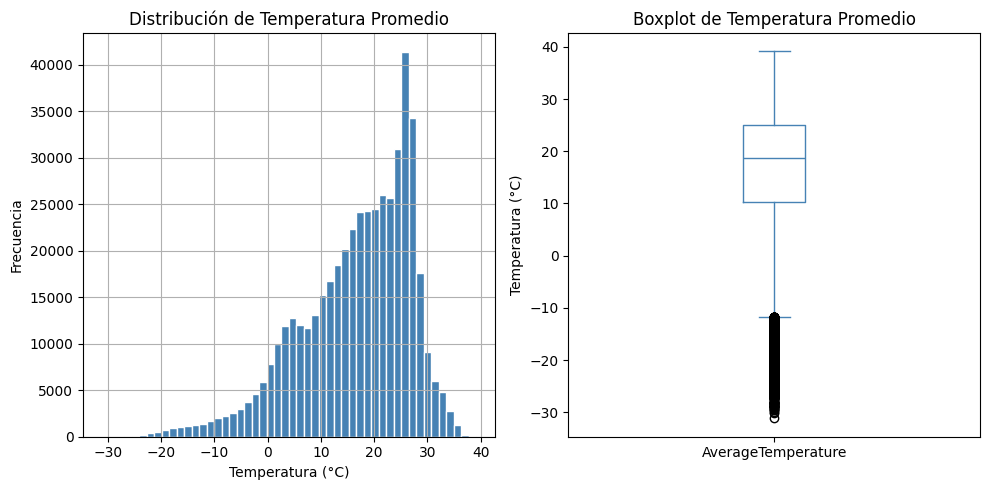

In [5]:
import matplotlib.pyplot as plt

# Variables predictoras
predictoras = ['year', 'month', 'decade', 'century', 'lat_num', 'lon_num', 
               'is_northern', 'is_eastern', 'is_modern', 'month_sin', 'month_cos']

# Variable objetivo
objetivo = 'AverageTemperature'

print("🎯 Variable Objetivo:")
print(f"   → {objetivo}")
print(f"\n📊 Variables Predictoras ({len(predictoras)}):")
for p in predictoras:
    print(f"   → {p}")

print(f"\n📈 Estadísticas del objetivo:")
print(df[objetivo].describe())

# Gráfica de distribución
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df[objetivo].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de Temperatura Promedio')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
df[objetivo].plot(kind='box', color='steelblue')
plt.title('Boxplot de Temperatura Promedio')
plt.ylabel('Temperatura (°C)')

plt.tight_layout()
plt.show()